# Initialization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron
import warnings
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm


In [2]:
# Creating the data dictionary based on the Quarterly Demand Data table 
data = {
    "Segment": ["PREMIUM", "PREMIUM", "PREMIUM", "PREMIUM", "PERFORMANCE", "PERFORMANCE", "VALUE", "VALUE", "VALUE"],
    "Product": ["750w", "HDxt", "450w", "HDi", "Pioneer", "Voyager", "355 BRIVO/360 Optima", "Creator 8 Chnl.", "Explorer 16 Chnl."],
    "2012Q4": [23, 9, 71, 13, 0, 3, 44, 0, 0],
    "2013Q1": [31, 6, 59, 14, 0, 7, 35, 0, 0],
    "2013Q2": [20, 6, 56, 14, 0, 9, 44, 0, 0],
    "2013Q3": [32, 9, 54, 22, 0, 10, 49, 0, 0],
    "2013Q4": [41, 9, 78, 0, 0, 6, 44, 0, 0],
    "2014Q1": [0, 3, 63, 4, 0, 8, 39, 0, 0],
    "2014Q2": [0, 9, 64, 11, 0, 16, 41, 0, 0],
    "2014Q3": [0, 4, 67, 15, 0, 15, 55, 0, 0],
    "2014Q4": [0, 5, 72, 12, 0, 9, 68, 0, 0],
    "2015Q1": [0, 3, 43, 8, 0, 6, 45, 0, 4],
    "2015Q2": [4, 1, 55, 2, 0, 11, 47, 6, 7],
    "2015Q3": [3, 0, 69, 6, 6, 20, 60, 25, 34],
    "2015Q4": [12, 0, 76, 3, 10, 13, 71, 20, 29],
    "2016Q1": [22, 3, 59, 3, 12, 14, 32, 29, 22],
    "2016Q2": [30, 1, 69, 8, 17, 2, 37, 19, 33],
    "2016Q3": [28, 2, 68, 6, 14, 3, 30, 22, 50],
    "2016Q4": [27, 0, 72, 7, 14, 7, 35, 30, 30],
    "2017Q1": [26, 3, 38, 4, 14, 12, 31, 22, 38],
    "2017Q2": [20, 1, 50, 1, 14, 23, 21, 45, 0]
}

df = pd.DataFrame(data)

# Transforming the data for time-series analysis (Melt)
# This makes it easier to filter by product and run ARIMA
df_melted = df.melt(id_vars=["Segment", "Product"], var_name="Quarter", value_name="Demand")
df_melted["Quarter"] = pd.to_datetime(df_melted["Quarter"])

print(df_melted)

         Segment               Product    Quarter  Demand
0        PREMIUM                  750w 2012-10-01      23
1        PREMIUM                  HDxt 2012-10-01       9
2        PREMIUM                  450w 2012-10-01      71
3        PREMIUM                   HDi 2012-10-01      13
4    PERFORMANCE               Pioneer 2012-10-01       0
..           ...                   ...        ...     ...
166  PERFORMANCE               Pioneer 2017-04-01      14
167  PERFORMANCE               Voyager 2017-04-01      23
168        VALUE  355 BRIVO/360 Optima 2017-04-01      21
169        VALUE       Creator 8 Chnl. 2017-04-01      45
170        VALUE     Explorer 16 Chnl. 2017-04-01       0

[171 rows x 4 columns]


C:\Users\AdamTick\AppData\Local\Temp\ipykernel_30576\2249573641.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_melted["Quarter"] = pd.to_datetime(df_melted["Quarter"])


# Horizon Selected

Based on the information that we gathered, we will select the 3 month horizon as our forecasting horizon as it directly aligned with GE Healthcare's strategic goals.
We will list all the facts from the paper below:
1. "The high-level demand were translated into build schedules for the factories that began 62 days before the magnet build. At this point, the window was frozen, and production was locked in. On the other hand, magnet, which is the most critical component of the build has the longest manufacturing time of 28 days." (Production & Outsourcing Problem)
2. "A corporate audit discovered that more than $12 billion was trapped in global supply chain in the form of inventory, with the MR division alone had approximately $100 million in trapped inventory". (Financial & Inventory Problems)
3. "If forecast are off by more than 10%, the MR division faces shortages that siginificant affect its ability to deliver on time for a customer. On the other hand, the position of GE being the second in the marketplace in the highest market for them, the US, put more pressure on minimizing costly shortages." (Customer Expectations & Sales Prblem)

Choosing a three-month forecasting horizon is the best strategic choice since it fits perfectly with GE Healthcare's strict production schedules and lowers both financial and market risks. Operationally, high-level demand estimates mean that factory construction schedules are set in stone exactly 62 days before the magnet manufacture starts. The magnet itself, which is the most important part, needs a 28-day manufacturing cycle. Forecasting at this exact 90-day mark gives the most accurate data just before resources are permanently committed. This is an important way to protect against overproduction, which has caused $12 billion in trapped global inventory, including $100 million in the MR division alone. Also, because forecast errors of more than 10% lead to big delivery shortages, this shorter three-month window lowers the chance of expensive delays, allowing GE to better meet customer needs and keep its important 25% market share as the second-largest MRI provider in the U.S. market, which is very competitive.

# Stationarity Analysis

## Graph

### High Level 

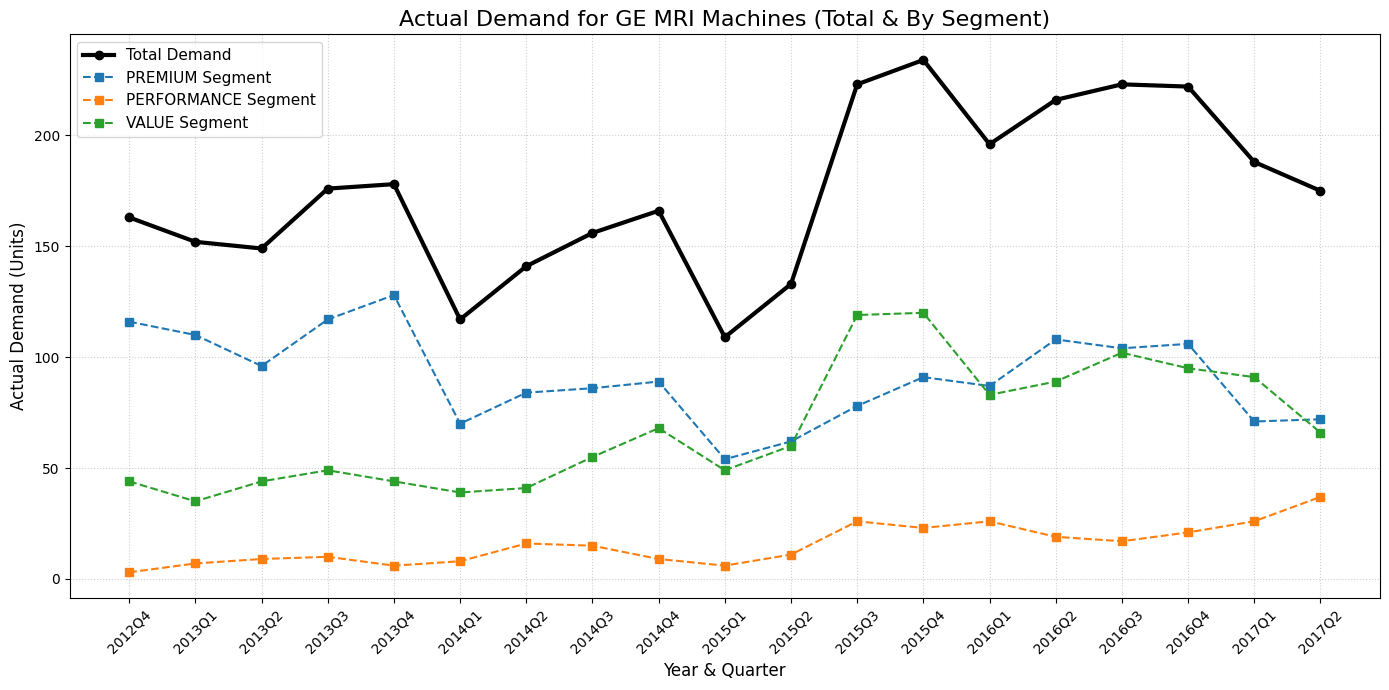

In [3]:
# 2. Create the DataFrame and transform it into a time-series friendly format
df = pd.DataFrame(data)
df_melted = df.melt(id_vars=["Segment", "Product"], var_name="Quarter", value_name="Demand")

# 3. Group the data for plotting
# Total overall demand per quarter
total_demand = df_melted.groupby("Quarter", sort=False)["Demand"].sum().reset_index()
# Demand broken down by segment per quarter
segment_demand = df_melted.groupby(["Quarter", "Segment"], sort=False)["Demand"].sum().reset_index()

# 4. Initialize the plot
plt.figure(figsize=(14, 7))

# Plot the Total Demand line (thick black line)
plt.plot(total_demand["Quarter"], total_demand["Demand"], marker='o', linewidth=3, color='black', label='Total Demand')

# Plot the individual Segment lines (dashed lines)
segments = df_melted["Segment"].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Distinct colors for the 3 segments

for segment, color in zip(segments, colors):
    seg_data = segment_demand[segment_demand["Segment"] == segment]
    plt.plot(seg_data["Quarter"], seg_data["Demand"], marker='s', linestyle='--', color=color, label=f'{segment} Segment')

# 5. Add titles, labels, and formatting
plt.title('Actual Demand for GE MRI Machines (Total & By Segment)', fontsize=16)
plt.xlabel('Year & Quarter', fontsize=12)
plt.ylabel('Actual Demand (Units)', fontsize=12)
plt.xticks(rotation=45) # Rotates the X-axis labels so they don't overlap
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

# 6. Display the plot
plt.show()

### Machine Level

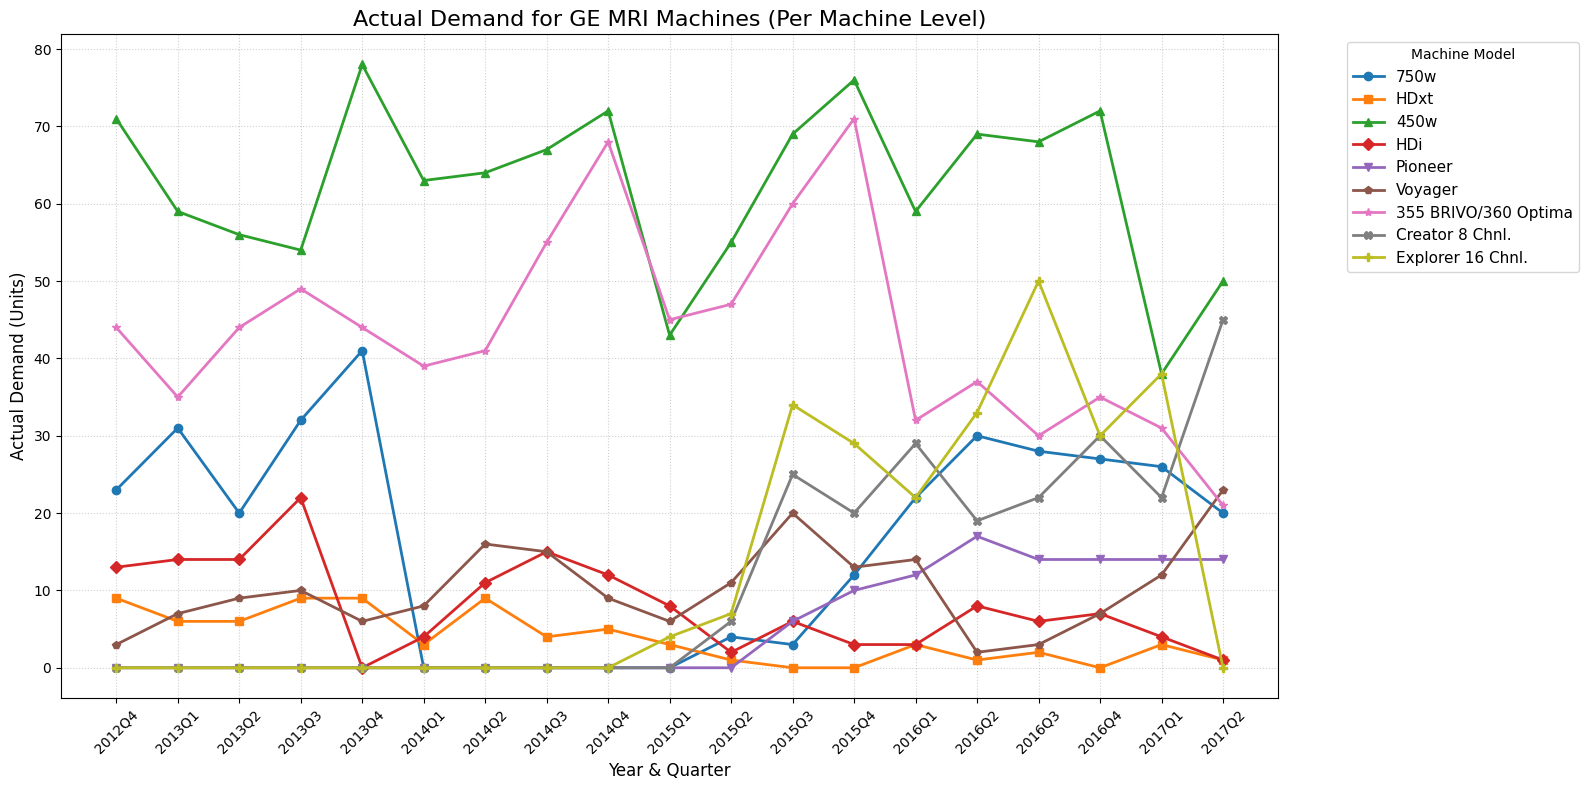

In [6]:
# 2. Load into a DataFrame and transform it into a time-series format
df = pd.DataFrame(data)
df_melted = df.melt(id_vars=["Segment", "Product"], var_name="Quarter", value_name="Demand")

# 3. Initialize the plot
plt.figure(figsize=(16, 8))

# 4. Extract unique products and set up a list of distinct markers
products = df_melted["Product"].unique()
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X', 'P']

# 5. Loop through each product and plot its line
for product, marker in zip(products, markers):
    prod_data = df_melted[df_melted["Product"] == product]
    plt.plot(prod_data["Quarter"], prod_data["Demand"], marker=marker, linewidth=2, label=product)

# 6. Add titles, labels, and formatting
plt.title('Actual Demand for GE MRI Machines (Per Machine Level)', fontsize=16)
plt.xlabel('Year & Quarter', fontsize=12)
plt.ylabel('Actual Demand (Units)', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for readability
plt.grid(True, linestyle=':', alpha=0.6)

# 7. Format the legend to sit outside the plot area
plt.legend(title='Machine Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout() # Ensures the legend and labels don't get cut off

# 8. Display the plot
plt.show()

# Statistical Stationary Function

## Function

In [ ]:
warnings.filterwarnings("ignore")
def run_stationarity_tests(series, product_name):
    print(f"=== Stationarity Tests for: {product_name} ===")
    
    # 1. Augmented Dickey-Fuller (ADF) Test
    # Null Hypothesis (H0): The series has a unit root (Non-Stationary)
    adf_result = adfuller(series.dropna())
    print(f"1. ADF Test:")
    print(f"   Test Statistic: {adf_result[0]:.4f}")
    print(f"   p-value: {adf_result[1]:.4f}")
    print("   Conclusion: " + ("Stationary (Reject H0)" if adf_result[1] < 0.05 else "Non-Stationary (Fail to reject H0)"))
    
    # 2. Phillips-Perron (PP) Test
    # Null Hypothesis (H0): The series has a unit root (Non-Stationary)
    pp_test = PhillipsPerron(series.dropna())
    print(f"\n2. Phillips-Perron Test:")
    print(f"   Test Statistic: {pp_test.stat:.4f}")
    print(f"   p-value: {pp_test.pvalue:.4f}")
    print("   Conclusion: " + ("Stationary (Reject H0)" if pp_test.pvalue < 0.05 else "Non-Stationary (Fail to reject H0)"))
    
    # 3. KPSS Test
    # Null Hypothesis (H0): The series is stationary (Trend-Stationary)
    # Note: The null hypothesis here is the OPPOSITE of ADF and PP!
    kpss_result = kpss(series.dropna(), regression='c', nlags="auto")
    print(f"\n3. KPSS Test:")
    print(f"   Test Statistic: {kpss_result[0]:.4f}")
    print(f"   p-value: {kpss_result[1]:.4f}")
    print("   Conclusion: " + ("Non-Stationary (Reject H0)" if kpss_result[1] < 0.05 else "Stationary (Fail to reject H0)"))
    print("="*45 + "\n")

## Stationary Test Execution

In [ ]:
results_list = []

for product in df_melted['Product'].unique():
    # Extract the series for the specific machine
    series = df_melted[df_melted['Product'] == product]['Demand'].dropna()
    
    # Default values in case a test fails (e.g., due to too many zeros/constant data)
    adf_res_str = "Test Error"
    pp_res_str = "Test Error"
    kpss_res_str = "Test Error"
    
    # 1. ADF Test (H0: Non-Stationary)
    try:
        adf_pvalue = adfuller(series)[1]
        adf_res_str = "Stationary" if adf_pvalue < 0.05 else "Not Stationary"
    except Exception:
        pass
        
    # 2. Phillips-Perron Test (H0: Non-Stationary)
    try:
        pp_pvalue = PhillipsPerron(series).pvalue
        pp_res_str = "Stationary" if pp_pvalue < 0.05 else "Not Stationary"
    except Exception:
        pass
        
    # 3. KPSS Test (H0: Stationary)
    try:
        kpss_pvalue = kpss(series, regression='c', nlags="auto")[1]
        # Notice the flipped logic for KPSS!
        kpss_res_str = "Not Stationary" if kpss_pvalue < 0.05 else "Stationary"
    except Exception:
        pass
        
    # Append the results for this machine to our list
    results_list.append({
        "Name of the Machine Level": product,
        "ADF Test Result": adf_res_str,
        "PP Test Result": pp_res_str,
        "KPSS Test result": kpss_res_str
    })

# Convert the list of dictionaries into a pandas DataFrame
results_df = pd.DataFrame(results_list)

# Display the final table
print(results_df)

Name of the Machine Level ADF Test Result PP Test Result KPSS Test result
                     750w  Not Stationary Not Stationary       Stationary
                     HDxt  Not Stationary Not Stationary   Not Stationary
                     450w  Not Stationary     Stationary       Stationary
                      HDi      Stationary Not Stationary   Not Stationary
                  Pioneer  Not Stationary Not Stationary   Not Stationary
                  Voyager      Stationary Not Stationary       Stationary
     355 BRIVO/360 Optima      Stationary Not Stationary       Stationary
          Creator 8 Chnl.      Stationary Not Stationary   Not Stationary
        Explorer 16 Chnl.  Not Stationary Not Stationary   Not Stationary


C:\Users\AdamTick\AppData\Local\Temp\ipykernel_26488\3519621388.py:28: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_pvalue = kpss(series, regression='c', nlags="auto")[1]
C:\Users\AdamTick\AppData\Local\Temp\ipykernel_26488\3519621388.py:28: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_pvalue = kpss(series, regression='c', nlags="auto")[1]
C:\Users\AdamTick\AppData\Local\Temp\ipykernel_26488\3519621388.py:28: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_pvalue = kpss(series, regression='c', nlags="auto")[1]
C:\Users\AdamTick\AppData\Local\Temp\ipykernel_26488\3519621388.py:28: InterpolationWarning: The tes

## ACF & PACF Correlogram

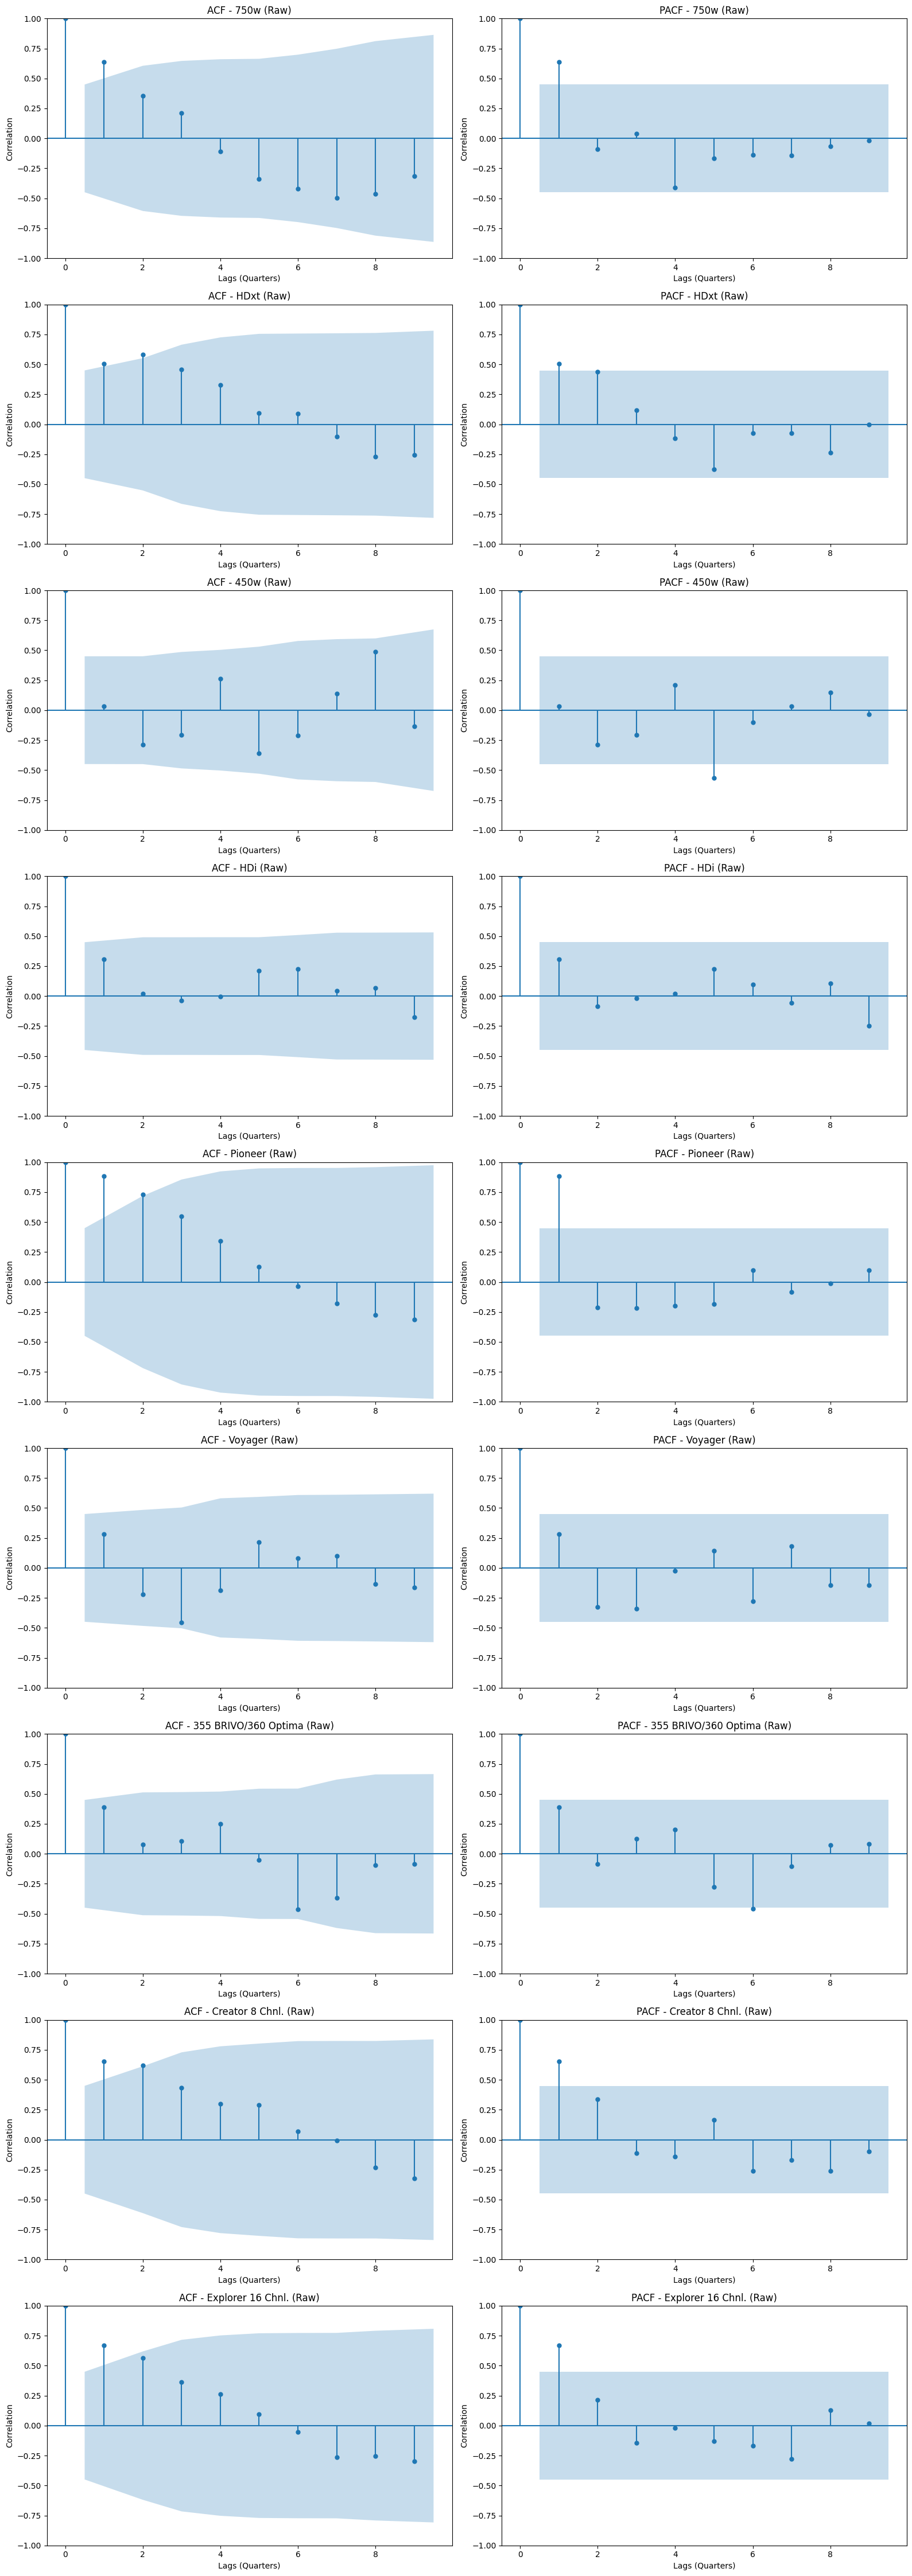

In [3]:
# 1. Get a list of all unique products in your dataframe
all_products = df_melted['Product'].unique()
no_lags = 9
# 2. Set up the plotting area 
# Rows = number of products, Columns = 2 (one for ACF, one for PACF)
# We dynamically adjust the height based on how many products there are
fig, axes = plt.subplots(len(all_products), 2, figsize=(16, 5 * len(all_products)))

if len(all_products) == 1:
    axes = [axes]

# 3. Loop through each product and create its plots
for i, product in enumerate(all_products):
    
    # 1. Isolate the RAW product demand
    series_raw = df_melted[df_melted['Product'] == product]['Demand'].dropna()
    
    # 2. Plot ACF on the RAW data
    plot_acf(series_raw, ax=axes[i, 0], lags=no_lags, title=f'ACF - {product} (Raw)')
    axes[i, 0].set_xlabel('Lags (Quarters)')
    axes[i, 0].set_ylabel('Correlation')
    
    # 3. Plot PACF on the RAW data
    plot_pacf(series_raw, ax=axes[i, 1], lags=no_lags, method='ywm', title=f'PACF - {product} (Raw)')
    axes[i, 1].set_xlabel('Lags (Quarters)')
    axes[i, 1].set_ylabel('Correlation')

plt.tight_layout()
plt.show()

# ARIMA Test

In [39]:
# Rolling ARIMA 
results_list_arima = []
test_quarters = 4

for product in all_products:
    series = df_melted[df_melted['Product'] == product]['Demand'].dropna().reset_index(drop=True)
    
    if len(series) <= test_quarters:
        print(f"{product}: Not enough data. Skipping.")
        continue

    # 1. Initial Split
    train_data = list(series.iloc[:-test_quarters])
    test_data = series.iloc[-test_quarters:].values
    rolling_predictions = []

    try:
        for i in range(test_quarters):
            # Fit model on the current training data
            model = pm.auto_arima(train_data, 
                                  start_p=0, max_p=3, 
                                  start_q=0, max_q=3,
                                  d=None, seasonal=False, 
                                  stepwise=True, 
                                  suppress_warnings=True)
            
            pred = model.predict(n_periods=1)[0]
            rolling_predictions.append(pred)
            
            # THE "ROLL"
            actual_val = test_data[i]
            train_data.append(actual_val)

        # Calculate metrics 
        rolling_predictions = np.array(rolling_predictions)
        mse = ((rolling_predictions - test_data) ** 2).mean()
        rmse = np.sqrt(mse)

        results_list_arima.append({
            'Product': product,
            'Best_ARIMA_Order': model.order, 
            'Initial_Train_Size': len(series) - test_quarters,
            'Test_Size': test_quarters,
            'MSE_Rolling': round(mse, 2),
            'RMSE_Rolling': round(rmse, 2),
        })
        
        
    except Exception as e:
        print(f"{product}: Failed. Error: {e}")

df_results_arima = pd.DataFrame(results_list_arima)
print("\n--- Final Rolling Results ---")
print(df_results_arima)


--- Final Rolling Results ---
                Product Best_ARIMA_Order  Initial_Train_Size  Test_Size  \
0                  750w        (1, 0, 0)                  15          4   
1                  HDxt        (1, 1, 0)                  15          4   
2                  450w        (0, 0, 0)                  15          4   
3                   HDi        (0, 0, 0)                  15          4   
4               Pioneer        (0, 1, 0)                  15          4   
5               Voyager        (2, 0, 0)                  15          4   
6  355 BRIVO/360 Optima        (0, 0, 1)                  15          4   
7       Creator 8 Chnl.        (0, 1, 0)                  15          4   
8     Explorer 16 Chnl.        (0, 1, 0)                  15          4   

   MSE_Rolling  RMSE_Rolling  
0        10.29          3.21  
1         1.44          1.20  
2       237.23         15.40  
3        22.46          4.74  
4         8.55          2.92  
5        45.87          6.77  
6

# ARIMAX

## Implementing 3-months qualitative forecast from regional inventory leader

In [40]:
data_3m = {
    'Segment': ['PREMIUM']*4 + ['PERFORMANCE']*2 + ['VALUE']*3,
    'Product': [
        '750w', 'HDxt', '450w', 'HDi', 
        'Pioneer', 'Voyager', 
        '355 BRIVO/360 Optima', 'Creator 8 Chnl.', 'Explorer 16 Chnl.'
    ],
    '2012Q4': [28.0, 9.0, 62.0, 10.0, 0.0, 2.0, 53.0, 0.0, 0.0],
    '2013Q1': [32.0, 2.0, 70.0, 11.0, 0.0, 7.0, 39.0, 0.0, 0.0],
    '2013Q2': [30.0, 8.0, 53.0, 11.0, 0.0, 11.0, 44.0, 0.0, 0.0],
    '2013Q3': [30.0, 7.0, 51.0, 27.0, 0.0, 12.0, 50.0, 0.0, 0.0],
    '2013Q4': [40.0, 11.0, 77.0, 0.0, 0.0, 9.0, 58.0, 0.0, 0.0],
    '2014Q1': [0.0, 4.0, 68.0, 2.0, 0.0, 6.0, 41.0, 0.0, 0.0],
    '2014Q2': [0.0, 7.0, 72.0, 12.0, 0.0, 15.0, 42.0, 0.0, 0.0],
    '2014Q3': [0.0, 5.0, 76.0, 19.0, 0.0, 15.0, 65.0, 0.0, 0.0],
    '2014Q4': [0.0, 4.0, 79.0, 10.0, 0.0, 9.0, 61.0, 0.0, 1.0],
    '2015Q1': [0.0, 3.0, 49.0, 9.0, 0.0, 12.0, 58.0, 0.0, 1.0],
    '2015Q2': [3.0, 1.0, 60.0, 4.0, 8.0, 12.0, 52.0, 6.0, 11.0],
    '2015Q3': [2.0, 0.0, 75.0, 5.0, 8.0, 20.0, 59.0, 21.0, 33.0],
    '2015Q4': [9.0, 3.0, 91.0, 5.0, 15.0, 12.0, 84.0, 31.0, 35.0],
    '2016Q1': [29.06, 3.0, 70.0, 6.0, 12.0, 17.0, 25.85, 41.07, 35.1],
    '2016Q2': [33.0, 0.0, 72.0, 11.0, 17.0, 4.0, 34.0, 41.0, 51.0],
    '2016Q3': [36.0, 2.0, 83.0, 7.0, 20.0, 5.0, 38.0, 49.0, 69.0],
    '2016Q4': [37.0, 1.0, 87.0, 5.0, 28.0, 16.0, 35.0, 54.0, 75.0],
    '2017Q1': [31.0, 2.0, 50.0, 6.0, 21.0, 18.0, 32.0, 42.0, 60.0],
    '2017Q2': [22.0, 1.0, 56.0, 2.0, 14.0, 30.0, 25.0, 52.0, 0.0]
}

df_3m_wide = pd.DataFrame(data_3m)

# Melt and transform Quarter to datetime
df_forecast_3m = df_3m_wide.melt(id_vars=["Segment", "Product"], var_name="Quarter", value_name="Forecast_3M")
df_forecast_3m["Quarter"] = pd.to_datetime(df_forecast_3m["Quarter"])
print(df_forecast_3m)

# Merging
df_melted_arimax = pd.merge(df_melted, df_forecast_3m, on=['Product', 'Quarter'], how='left')

         Segment               Product    Quarter  Forecast_3M
0        PREMIUM                  750w 2012-10-01         28.0
1        PREMIUM                  HDxt 2012-10-01          9.0
2        PREMIUM                  450w 2012-10-01         62.0
3        PREMIUM                   HDi 2012-10-01         10.0
4    PERFORMANCE               Pioneer 2012-10-01          0.0
..           ...                   ...        ...          ...
166  PERFORMANCE               Pioneer 2017-04-01         14.0
167  PERFORMANCE               Voyager 2017-04-01         30.0
168        VALUE  355 BRIVO/360 Optima 2017-04-01         25.0
169        VALUE       Creator 8 Chnl. 2017-04-01         52.0
170        VALUE     Explorer 16 Chnl. 2017-04-01          0.0

[171 rows x 4 columns]


C:\Users\AdamTick\AppData\Local\Temp\ipykernel_30576\2624834936.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_forecast_3m["Quarter"] = pd.to_datetime(df_forecast_3m["Quarter"])


In [41]:
results_list_arimax = [] 
test_quarters = 4

# Define the exact best orders
best_arima_orders = {
    "750w": (1, 0, 0),
    "HDxt": (1, 1, 0),
    "450w": (0, 0, 0),
    "HDi": (0, 0, 0),
    "Pioneer": (0, 1, 0),
    "Voyager": (2, 0, 0),
    "355 BRIVO/360 Optima": (0, 0, 1),
    "Creator 8 Chnl.": (0, 1, 0),
    "Explorer 16 Chnl.": (0, 1, 0)
}

df_melted_arimax['Forecast_3M'] = df_melted_arimax['Forecast_3M'].fillna(0)

for product in all_products:
    # Force the model to use ONLY the predefined best order from above ARIMA
    product_order = best_arima_orders.get(product, (0, 0, 0))
    
    df_p = df_melted_arimax[df_melted_arimax['Product'] == product].sort_values('Quarter').reset_index(drop=True)
    df_p = df_p.dropna(subset=['Demand', 'Forecast_3M'])
    
    series_y = df_p['Demand']
    series_X = df_p['Forecast_3M']
    
    if len(series_y) <= test_quarters:
        continue

    # Split Train/Test
    train_y = list(series_y.iloc[:-test_quarters])
    test_y = series_y.iloc[-test_quarters:].values
    train_X = list(series_X.iloc[:-test_quarters])
    test_X = series_X.iloc[-test_quarters:].values
    
    rolling_predictions = []

    try:
        # Rolling Loop 
        for i in range(test_quarters):
            curr_train_X = np.array(train_X).reshape(-1, 1)
            
            model = pm.ARIMA(order=product_order, suppress_warnings=True)
            model.fit(train_y, X=curr_train_X)
            
            # Predict 1-step ahead
            next_X = np.array([[test_X[i]]])
            pred = model.predict(n_periods=1, X=next_X)[0] 
            rolling_predictions.append(pred)
            
            # The "Roll"
            train_y.append(test_y[i])
            train_X.append(test_X[i])

        # Calculate Metrics
        rolling_predictions = np.array(rolling_predictions)
        mse = ((rolling_predictions - test_y) ** 2).mean()
        rmse = np.sqrt(mse)

        # Append exact results
        results_list_arimax.append({
            'Product': product,
            'ARIMAX_Order': product_order,
            'Initial_Train_Size': len(series) - test_quarters,
            'Test_Size': test_quarters,
            'MSE_Rolling': round(mse, 2),
            'RMSE_Rolling': round(rmse, 2),
        })
        
    except Exception as e:
        print(f'{product} failed: {e}')

# Create final dataframe
df_results_arimax_3mo = pd.DataFrame(results_list_arimax)

# Display the clean output
print(df_results_arimax_3mo)

                Product ARIMAX_Order  Initial_Train_Size  Test_Size  \
0                  750w    (1, 0, 0)                  15          4   
1                  HDxt    (1, 1, 0)                  15          4   
2                  450w    (0, 0, 0)                  15          4   
3                   HDi    (0, 0, 0)                  15          4   
4               Pioneer    (0, 1, 0)                  15          4   
5               Voyager    (2, 0, 0)                  15          4   
6  355 BRIVO/360 Optima    (0, 0, 1)                  15          4   
7       Creator 8 Chnl.    (0, 1, 0)                  15          4   
8     Explorer 16 Chnl.    (0, 1, 0)                  15          4   

   MSE_Rolling  RMSE_Rolling  
0        19.28          4.39  
1         1.34          1.16  
2        61.66          7.85  
3         2.96          1.72  
4         6.20          2.49  
5        14.22          3.77  
6         6.30          2.51  
7        73.84          8.59  
8       31

## Moodys AAA Yield

In [42]:
moody_AAA = pd.read_csv("Moody_AAA.csv")

In [43]:
# Convert and average per quarter
moody_AAA['date'] = pd.to_datetime(moody_AAA['date'])
moody_AAA['Quarter'] = moody_AAA['date'].dt.to_period('Q')
df_quarterly_avg_moody = moody_AAA.groupby('Quarter')['Moody_AAA'].mean().reset_index()
df_quarterly_avg_moody = df_quarterly_avg_moody.rename(columns={'Moody_AAA': 'average_aaa'})

# Convert back to timestamp for merging
df_quarterly_avg_moody["Quarter"] = df_quarterly_avg_moody["Quarter"].dt.to_timestamp()

# Ensure chronological order before rolling
df_quarterly_avg_moody = df_quarterly_avg_moody.sort_values('Quarter').reset_index(drop=True)

# Create rolling averages and std dev, then shift by 1 (lag)
df_quarterly_avg_moody['AAA_RollMean_2Q_Lag1'] = df_quarterly_avg_moody['average_aaa'].rolling(window=2).mean().shift(1)
df_quarterly_avg_moody['AAA_RollMean_4Q_Lag1'] = df_quarterly_avg_moody['average_aaa'].rolling(window=4).mean().shift(1)
df_quarterly_avg_moody['AAA_RollStd_4Q_Lag1'] = df_quarterly_avg_moody['average_aaa'].rolling(window=4).std().shift(1) 

df_merged = pd.merge(df_melted_arimax, df_quarterly_avg_moody, on='Quarter', how='left')

In [44]:
results_list_arimax  = [] 
test_quarters = 4

best_arima_orders = {
    "750w": (1, 0, 0),
    "HDxt": (1, 1, 0),
    "450w": (0, 0, 0),
    "HDi": (0, 0, 0),
    "Pioneer": (0, 1, 0),
    "Voyager": (2, 0, 0),
    "355 BRIVO/360 Optima": (0, 0, 1),
    "Creator 8 Chnl.": (0, 1, 0),
    "Explorer 16 Chnl.": (0, 1, 0)
}

# Define Moody AAA exogenous features list
exog_features = ['AAA_RollMean_2Q_Lag1', 'AAA_RollMean_4Q_Lag1', 'AAA_RollStd_4Q_Lag1']

for product in all_products:
    product_order = best_arima_orders.get(product, (0, 0, 0))
    
    # Isolate product data using the NEW merged dataframe
    df_p = df_merged[df_merged['Product'] == product].sort_values('Quarter').reset_index(drop=True)
    
    # Drop NaN data (from the lagged features at the start of the time series)
    df_p = df_p.dropna(subset=['Demand'] + exog_features)
    
    # Isolate Series
    series_y = df_p['Demand']
    df_X = df_p[exog_features]
    
    if len(series_y) <= test_quarters:
        print(f"d{product} skipped: Not enough data after dropping NaNs.")
        continue

    # Split Train/Test
    train_y = list(series_y.iloc[:-test_quarters])
    test_y = series_y.iloc[-test_quarters:].values
    
    train_X = df_X.iloc[:-test_quarters].values.tolist()
    test_X = df_X.iloc[-test_quarters:].values 
    
    rolling_predictions = []

    try:
        # Rolling forecast loop
        for i in range(test_quarters):
            curr_train_X = np.array(train_X) 
            
            model = pm.ARIMA(order=product_order, suppress_warnings=True)
            model.fit(train_y, X=curr_train_X)
            
            next_X = test_X[i].reshape(1, -1) 
            pred = model.predict(n_periods=1, X=next_X)[0] 
            rolling_predictions.append(pred)
            
            # The "Roll"
            train_y.append(test_y[i])
            train_X.append(list(test_X[i]))

        # Calculate Metrics
        rolling_predictions = np.array(rolling_predictions)
        mse = ((rolling_predictions - test_y) ** 2).mean()
        rmse = np.sqrt(mse)

        # Append exact results
        results_list_arimax.append({
            'Product': product,
            'ARIMAX_Order': product_order,
            'Initial_Train_Size': len(series_y) - test_quarters,
            'Test_Size': test_quarters,
            'MSE_Rolling': round(mse, 2),
            'RMSE_Rolling': round(rmse, 2)
        })
        
    except Exception as e:
        print(f"❌ {product} failed: {e}")

# Create final dataframe
df_results_arimax_moody = pd.DataFrame(results_list_arimax)

print(df_results_arimax_moody)

                Product ARIMAX_Order  Initial_Train_Size  Test_Size  \
0                  750w    (1, 0, 0)                  15          4   
1                  HDxt    (1, 1, 0)                  15          4   
2                  450w    (0, 0, 0)                  15          4   
3                   HDi    (0, 0, 0)                  15          4   
4               Pioneer    (0, 1, 0)                  15          4   
5               Voyager    (2, 0, 0)                  15          4   
6  355 BRIVO/360 Optima    (0, 0, 1)                  15          4   
7       Creator 8 Chnl.    (0, 1, 0)                  15          4   
8     Explorer 16 Chnl.    (0, 1, 0)                  15          4   

   MSE_Rolling  RMSE_Rolling  
0        27.01          5.20  
1         3.59          1.89  
2       255.38         15.98  
3        20.31          4.51  
4         4.04          2.01  
5        42.07          6.49  
6       156.54         12.51  
7       159.23         12.62  
8       70

## 3-Mo & Moodys AAA

In [45]:
results_list_arimax  = [] 
test_quarters = 4

best_arima_orders = {
    "750w": (1, 0, 0),
    "HDxt": (1, 1, 0),
    "450w": (0, 0, 0),
    "HDi": (0, 0, 0),
    "Pioneer": (0, 1, 0),
    "Voyager": (2, 0, 0),
    "355 BRIVO/360 Optima": (0, 0, 1),
    "Creator 8 Chnl.": (0, 1, 0),
    "Explorer 16 Chnl.": (0, 1, 0)
}

for product in all_products:
    product_order = best_arima_orders.get(product, (0, 0, 0))
    
    # Isolate product data using the merged dataframe
    df_p = df_merged[df_merged['Product'] == product].sort_values('Quarter').reset_index(drop=True)
    
    # Define the FULL exogenous features list
    exog_features = [
        'AAA_RollMean_2Q_Lag1', 
        'AAA_RollMean_4Q_Lag1', 
        'AAA_RollStd_4Q_Lag1',
        'Forecast_3M',        
    ]
    
    # Drop NaN data
    df_p = df_p.dropna(subset=['Demand'] + exog_features)
    
    # Isolate Series
    series_y = df_p['Demand']
    df_X = df_p[exog_features]
    
    if len(series_y) <= test_quarters:
        print(f"{product} skipped: Not enough data after dropping NaNs.")
        continue

    # Split Train/Test
    train_y = list(series_y.iloc[:-test_quarters])
    test_y = series_y.iloc[-test_quarters:].values
    
    train_X = df_X.iloc[:-test_quarters].values.tolist()
    test_X = df_X.iloc[-test_quarters:].values 
    
    rolling_predictions = []

    try:
        # Rolling forecast loop
        for i in range(test_quarters):
            curr_train_X = np.array(train_X) 
            
            model = pm.ARIMA(order=product_order, suppress_warnings=True)
            model.fit(train_y, X=curr_train_X)
            
            next_X = test_X[i].reshape(1, -1) 
            pred = model.predict(n_periods=1, X=next_X)[0] 
            rolling_predictions.append(pred)
            
            # The "Roll"
            train_y.append(test_y[i])
            train_X.append(list(test_X[i]))

        # Calculate Metrics
        rolling_predictions = np.array(rolling_predictions)
        mse = ((rolling_predictions - test_y) ** 2).mean()
        rmse = np.sqrt(mse)
        wmape = (np.sum(np.abs(test_data - rolling_predictions)) / np.sum(test_data)) * 100

        # Append exact results
        results_list_arimax.append({
            'Product': product,
            'ARIMAX_Order': product_order,
            'Initial_Train_Size': len(series_y) - test_quarters,
            'Test_Size': test_quarters,
            'MSE_Rolling': round(mse, 2),
            'RMSE_Rolling': round(rmse, 2),
        })
        
    except Exception as e:
        print(f"{product} failed: {e}")

# Create final dataframe
df_results_arimax_moody_3mo = pd.DataFrame(results_list_arimax)

print(df_results_arimax_moody_3mo)

                Product ARIMAX_Order  Initial_Train_Size  Test_Size  \
0                  750w    (1, 0, 0)                  15          4   
1                  HDxt    (1, 1, 0)                  15          4   
2                  450w    (0, 0, 0)                  15          4   
3                   HDi    (0, 0, 0)                  15          4   
4               Pioneer    (0, 1, 0)                  15          4   
5               Voyager    (2, 0, 0)                  15          4   
6  355 BRIVO/360 Optima    (0, 0, 1)                  15          4   
7       Creator 8 Chnl.    (0, 1, 0)                  15          4   
8     Explorer 16 Chnl.    (0, 1, 0)                  15          4   

   MSE_Rolling  RMSE_Rolling  
0        27.10          5.21  
1         1.36          1.17  
2        70.99          8.43  
3         3.60          1.90  
4         1.29          1.14  
5        12.34          3.51  
6        13.03          3.61  
7       101.44         10.07  
8       30

# Final Comparison

In [ ]:
# 1. Rename columns in the 3MO dataframe
df_results_arimax_3mo = df_results_arimax_3mo.rename(columns={
    'ARIMAX_Order': 'Best_ARIMA_Order', # Align key name with df_results_arima
    'MSE_Rolling': 'MSE_Rolling_3MO',
    'RMSE_Rolling': 'RMSE_Rolling_3MO'
})

# 2. Rename columns in the Moody dataframe
df_results_arimax_moody = df_results_arimax_moody.rename(columns={
    'ARIMAX_Order': 'Best_ARIMA_Order',
    'MSE_Rolling': 'MSE_Rolling_Moody',
    'RMSE_Rolling': 'RMSE_Rolling_Moody'
})

# 3. Rename columns in the combined Moody + 3MO dataframe
df_results_arimax_moody_3mo = df_results_arimax_moody_3mo.rename(columns={
    'ARIMAX_Order': 'Best_ARIMA_Order',
    'MSE_Rolling': 'MSE_Rolling_Moody_3MO',
    'RMSE_Rolling': 'RMSE_Rolling_Moody_3MO'
})

# 4. Filter out redundant columns (like Train_Size and Test_Size) 
# so they don't get duplicated in the final merged dataframe.
cols_3mo = ['Product', 'Best_ARIMA_Order', 'MSE_Rolling_3MO', 'RMSE_Rolling_3MO']
cols_moody = ['Product', 'Best_ARIMA_Order', 'MSE_Rolling_Moody', 'RMSE_Rolling_Moody']
cols_combined = ['Product', 'Best_ARIMA_Order', 'MSE_Rolling_Moody_3MO', 'RMSE_Rolling_Moody_3MO']

# 5. Execute the sequential merges starting with the base ARIMA dataframe
df_final_comparison = df_results_arima.merge(
    df_results_arimax_3mo[cols_3mo], 
    on=['Product', 'Best_ARIMA_Order'], 
    how='left'
).merge(
    df_results_arimax_moody[cols_moody], 
    on=['Product', 'Best_ARIMA_Order'], 
    how='left'
).merge(
    df_results_arimax_moody_3mo[cols_combined], 
    on=['Product', 'Best_ARIMA_Order'], 
    how='left'
)

# Find the lowest RMSE column
rmse_columns = [
    'RMSE_Rolling', 
    'RMSE_Rolling_3MO', 
    'RMSE_Rolling_Moody', 
    'RMSE_Rolling_Moody_3MO'
]

model_names = {
    'RMSE_Rolling': 'Base ARIMA',
    'RMSE_Rolling_3MO': 'ARIMAX (3-Month Forecast Qualitative)',
    'RMSE_Rolling_Moody': 'ARIMAX (Moody AAA)',
    'RMSE_Rolling_Moody_3MO': 'ARIMAX (Moody + 3-Month Forecast Qualitative)'
}

df_final_comparison['Best_Model'] = df_final_comparison[rmse_columns].idxmin(axis=1).map(model_names)

# Display the master comparison table
print(df_final_comparison)

                Product Best_ARIMA_Order  Initial_Train_Size  Test_Size  \
0                  750w        (1, 0, 0)                  15          4   
1                  HDxt        (1, 1, 0)                  15          4   
2                  450w        (0, 0, 0)                  15          4   
3                   HDi        (0, 0, 0)                  15          4   
4               Pioneer        (0, 1, 0)                  15          4   
5               Voyager        (2, 0, 0)                  15          4   
6  355 BRIVO/360 Optima        (0, 0, 1)                  15          4   
7       Creator 8 Chnl.        (0, 1, 0)                  15          4   
8     Explorer 16 Chnl.        (0, 1, 0)                  15          4   

   MSE_Rolling  RMSE_Rolling  MSE_Rolling_3MO  RMSE_Rolling_3MO  \
0        10.29          3.21            19.28              4.39   
1         1.44          1.20             1.34              1.16   
2       237.23         15.40            61.66   